# About Tha Data

link https://www.kaggle.com/datasets/fahadullaha/facial-emotion-recognition-dataset/data


This was a data source for a university project. This dataset was processed using FER2013 Dataset and RAFDB Dataset. Using various techniques like HaarCascade for filtering images with a face (at 0.8 confidence score), lower noise. The datasets were merged and the gray scale images from FER2013 was converted to RGB. This dataset provides a rich mix of images across 7 emotions. Note: Direct use of the dataset will cause issues due to class imbalance among the dataset classes.

## Imports

In [1]:
import numpy as np
import pandas as pd
import kagglehub
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
tf.get_logger().setLevel('ERROR')


2026-07-16 06:31:33.913964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784183494.112975      40 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784183494.161588      40 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Load The Data

In [2]:
# Download latest version
path = kagglehub.dataset_download("fahadullaha/facial-emotion-recognition-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/facial-emotion-recognition-dataset


In [3]:
IMAGE_SIZE = 96
BATCH_SIZE = 32
DATASET_DIR = '/kaggle/input/facial-emotion-recognition-dataset/processed_data'

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
n_classes = len(class_names)
print("Classes:", class_names)

Found 49779 files belonging to 7 classes.


I0000 00:00:1784183521.791358      40 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Explore A Bit

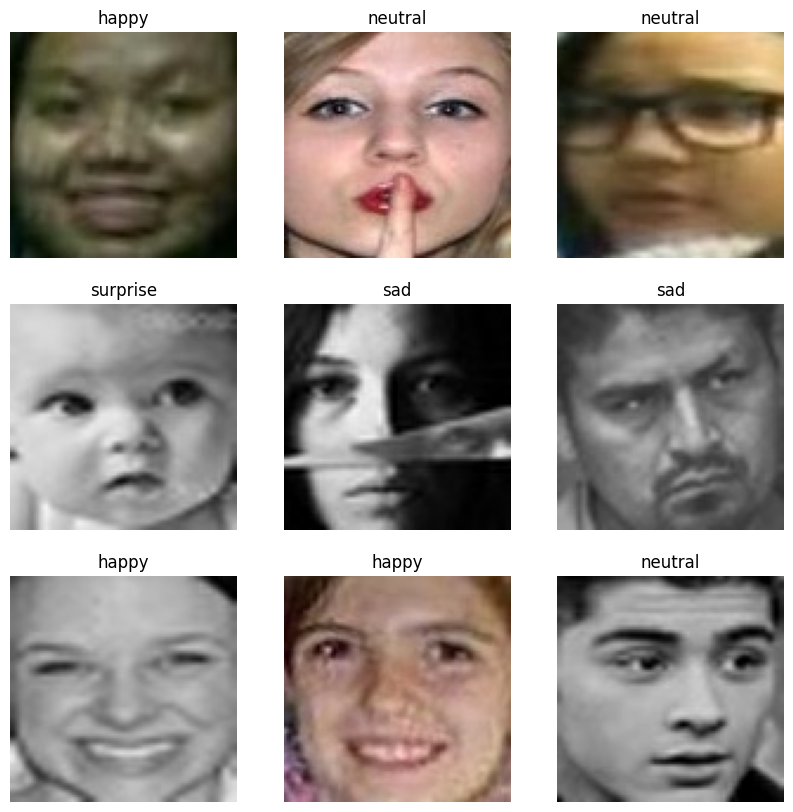

In [4]:
import matplotlib.pyplot as plt

# Take one batch from the dataset
for images, labels in dataset.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

## Train Test Validation

In [5]:
dataset_size = len(list(dataset))
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)

train_ds = dataset.take(train_size)
remaining = dataset.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

Train batches: 1244
Validation batches: 155
Test batches: 157


## Pipeline

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Data Augmentation

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
], name="aug")

## Model EfficientNetB0/B3

In [8]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(96,96,3)
)
base_model.trainable = False  # first freeze

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False


In [10]:
model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(96,96,3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
])

In [11]:

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
EPOCHS = 50

In [12]:
optimizer = keras.optimizers.AdamW(
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

loss = keras.losses.CategoricalCrossentropy(
    label_smoothing=LABEL_SMOOTHING
)

metrics = [
    "accuracy",
    keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_acc")
]

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/20


I0000 00:00:1784183571.612309     106 service.cc:148] XLA service 0x7ada94002550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784183571.613156     106 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1784183572.178093     106 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1784183578.510506     106 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1244/1244 - 60s - 48ms/step - accuracy: 0.4259 - loss: 1.6186 - val_accuracy: 0.3889 - val_loss: 1.6800 - learning_rate: 0.0010
Epoch 2/20
1244/1244 - 32s - 26ms/step - accuracy: 0.5299 - loss: 1.2311 - val_accuracy: 0.4625 - val_loss: 1.3493 - learning_rate: 0.0010
Epoch 3/20
1244/1244 - 32s - 26ms/step - accuracy: 0.5634 - loss: 1.1550 - val_accuracy: 0.4881 - val_loss: 1.3477 - learning_rate: 0.0010
Epoch 4/20
1244/1244 - 32s - 25ms/step - accuracy: 0.5912 - loss: 1.0897 - val_accuracy: 0.5962 - val_loss: 1.0663 - learning_rate: 0.0010
Epoch 5/20
1244/1244 - 31s - 25ms/step - accuracy: 0.6400 - loss: 0.9592 - val_accuracy: 0.4242 - val_loss: 1.6733 - learning_rate: 0.0010
Epoch 6/20
1244/1244 - 31s - 25ms/step - accuracy: 0.6809 - loss: 0.8619 - val_accuracy: 0.5278 - val_loss: 1.3613 - learning_rate: 0.0010
Epoch 7/20
1244/1244 - 32s - 25ms/step - accuracy: 0.7333 - loss: 0.7267 - val_accuracy: 0.6355 - val_loss: 1.0652 - learning_rate: 0.0010
Epoch 8/20
1244/1244 - 30s - 25ms/step

157/157 - 12s - 74ms/step - accuracy: 0.6330 - loss: 1.0425
✅ Test Accuracy: 63.30%


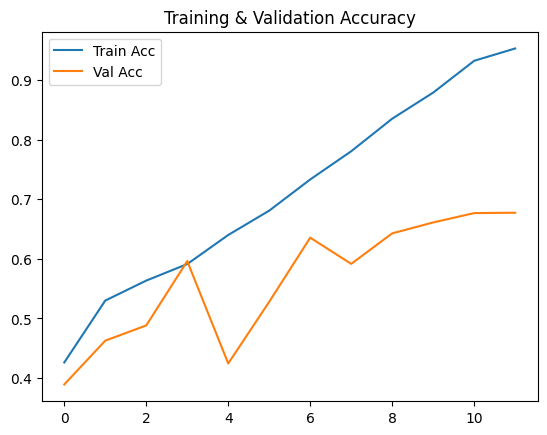

In [15]:
loss, acc = model.evaluate(test_ds,verbose=2)
print(f"✅ Test Accuracy: {acc*100:.2f}%")

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Training & Validation Accuracy")
plt.show()

## Confusion Matrix

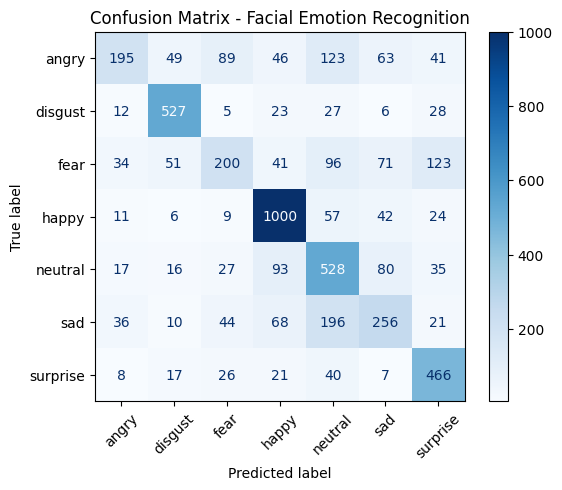

In [16]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images,verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix - Facial Emotion Recognition")
plt.show()

# Experiment 2 – MobileNetV3-Large

This experiment evaluates MobileNetV3-Large on the same processed facial emotion
recognition dataset used in Experiment 1.

To ensure a fair comparison, all preprocessing steps, data augmentation,
training hyperparameters, optimizer settings, and evaluation metrics remain
identical to Experiment 1. The only difference is the backbone architecture.

The objective is to compare the performance of EfficientNet-B0 and
MobileNetV3-Large for facial emotion recognition.

In [17]:
# =====================================================
# Experiment 2 Configuration
# =====================================================

from pathlib import Path

MODEL_VERSION = "mobilenet_v3_large_processed"

# Save directly to Kaggle working directory
MOBILENET_CHECKPOINT = Path("/kaggle/working/best_model_mobilenet_v3_large.pt")

print("Checkpoint will be saved to:")
print(MOBILENET_CHECKPOINT)

Checkpoint will be saved to:
/kaggle/working/best_model_mobilenet_v3_large.pt


In [19]:
from torchvision.models import (
    mobilenet_v3_large,
    MobileNet_V3_Large_Weights
)

def create_mobilenet_v3(num_classes=7):

    model = mobilenet_v3_large(
        weights=MobileNet_V3_Large_Weights.DEFAULT
    )

    in_features = model.classifier[3].in_features

    model.classifier[3] = torch.nn.Linear(
        in_features,
        num_classes
    )

    return model


def load_mobilenet_checkpoint(path, device):

    checkpoint = torch.load(
        path,
        map_location=device,
        weights_only=False
    )

    model = create_mobilenet_v3(
        checkpoint["num_classes"]
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.to(device)
    model.eval()

    return model, checkpoint

In [20]:
from tensorflow.keras import layers, models, optimizers
import tensorflow as tf

base_model = tf.keras.applications.MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(96, 96, 3)
)

# Freeze backbone
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax")
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 3, 3, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,245,191 (12.38 MB)

 Trainable params: 248,327 (970.03 KB)

 Non-trainable params: 2,996,864 (11.43 MB)

In [21]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.3797 - loss: 1.7751 - val_accuracy: 0.5022 - val_loss: 1.3261
Epoch 2/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4771 - loss: 1.3801 - val_accuracy: 0.5036 - val_loss: 1.2966
Epoch 3/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4953 - loss: 1.3430 - val_accuracy: 0.5159 - val_loss: 1.2646
Epoch 4/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5026 - loss: 1.3029 - val_accuracy: 0.5224 - val_loss: 1.2601
Epoch 5/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5089 - loss: 1.2908 - val_accuracy: 0.5196 - val_loss: 1.2549
Epoch 6/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5197 - loss: 1.2667 - val_accuracy: 0.5238 - val_loss: 1.2487
Epoch 7/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5258 - loss: 1.2476 - val_accuracy: 0.5347 - val_loss: 1.2406
Epoch 8/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5346 - loss: 

In [22]:
base_model.trainable = True

# Freeze all except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


E0000 00:00:1784184488.161899     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1784184488.345136     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1784184488.606086     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1784184488.809696     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1244/1244 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.4121 - loss: 1.5498 - val_accuracy: 0.5091 - val_loss: 1.3095
Epoch 2/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4551 - loss: 1.4152 - val_accuracy: 0.4960 - val_loss: 1.3246
Epoch 3/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4884 - loss: 1.3476 - val_accuracy: 0.4950 - val_loss: 1.3123
Epoch 4/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.5089 - loss: 1.3023 - val_accuracy: 0.5073 - val_loss: 1.2939
Epoch 5/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.5185 - loss: 1.2678 - val_accuracy: 0.5177 - val_loss: 1.2760
Epoch 6/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.5383 - loss: 1.2234 - val_accuracy: 0.5230 - val_loss: 1.2612
Epoch 7/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.5472 - loss: 1.1944 - val_accuracy: 0.5308 - val_loss: 1.2465
Epoch 8/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.5560 - loss: 1.17

In [24]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Accuracy: {test_acc:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5735 - loss: 1.1519
Test Accuracy: 0.5636


In [25]:
from IPython.display import FileLink

print("Download trained model:")
display(FileLink("/kaggle/working/best_model_mobilenet_v3_large.pt"))

print("\nDownload confusion matrix:")
display(FileLink("/kaggle/working/mobilenet_v3_confusion_matrix.png"))

Download trained model:


/kaggle/working/best_model_mobilenet_v3_large.pt


Download confusion matrix:


/kaggle/working/mobilenet_v3_confusion_matrix.png